# Chapter 2.2 — K-means Mis-cluster Extraction

This is the **Machine Learning** step of the project. It takes the Sentence-BERT text embeddings produced in 2.1 and runs K-means clustering with **K = 20**, deliberately matching the assignment's *20 fragments* requirement so that one cluster → one architectural fragment.

**The question this notebook answers.** Where does the model accidentally collapse documents from different sources together — i.e. where does it confuse a Reddit grief post, a Wayback dead-blog page, and an LoC unidentified photograph as belonging to the same semantic neighbourhood? Those mis-classifications are not a bug. They are the *generators* of the architecture in Chapter 3. The most cross-domain-confused cluster will produce the most thesis-aligned fragment.

**Pipeline.**
1. Load SBERT (text) embeddings + corpus metadata from `data/processed/`.
2. K-means (K=20, n_init=10, random_state=42).
3. For each cluster compute size, source-mixing score (Shannon entropy over source labels), top TF-IDF keywords, and a few sample texts.
4. Rank clusters by mixing — the top half become *high-confusion fragments*; the bottom half become *low-confusion fragments*. The Blender pipeline in Chapter 3 reads the rank as a design parameter.
5. Save cluster metadata + assignments to `data/processed/cluster_assignments.csv` and `Chapter_2/Clustering/Outputs/`.

**Why K=20 and not the elbow-method 'best' K.** The downstream architectural step needs exactly 20 design generators (assignment requirement). Choosing K to match the production constraint is the correct decision here. We also print the silhouette score to confirm K=20 is in a reasonable range, but it is not the criterion.

In [1]:
import sys, os, json
from pathlib import Path

def _find_project_root(marker="sa_utils.py"):
    p = Path.cwd().resolve()
    for c in [p] + list(p.parents):
        if (c / marker).exists(): return c
    cowork = Path.home() / "Library/Application Support/Claude/local-agent-mode-sessions"
    if cowork.exists():
        for hit in cowork.rglob(marker):
            return hit.parent
    raise FileNotFoundError(f"Could not find {marker}; set PROJECT_ROOT manually.")
PROJECT_ROOT = _find_project_root()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

from sa_utils import load_env, DATA_PROCESSED
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

load_env()
OUT_DIR = PROJECT_ROOT / "Chapter_2" / "Clustering" / "Outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")
print(f"Output dir:   {OUT_DIR}")

.env loaded. OPENAI_API_KEY present: True
Project root: /Users/rao/Library/Application Support/Claude/local-agent-mode-sessions/6b9b214c-10b0-4e49-8804-78fee7ba4cfe/65bc0ee0-83a2-418a-80ae-8b2eb8d6a0cd/local_cc966565-ccf9-44a8-bd4f-b759a867e830/outputs
Output dir:   /Users/rao/Library/Application Support/Claude/local-agent-mode-sessions/6b9b214c-10b0-4e49-8804-78fee7ba4cfe/65bc0ee0-83a2-418a-80ae-8b2eb8d6a0cd/local_cc966565-ccf9-44a8-bd4f-b759a867e830/outputs/Chapter_2/Clustering/Outputs


## 1. Load embeddings + metadata

In [2]:
X_sbert = np.load(DATA_PROCESSED / "X_sbert.npy")
df      = pd.read_csv(DATA_PROCESSED / "corpus_metadata.csv")
assert len(X_sbert) == len(df), "row count mismatch -- re-run text_vectorisation"
print(f"Loaded {len(df)} documents, embedding dim {X_sbert.shape[1]}")
print("\nPer-source counts:")
print(df["source"].value_counts().to_string())

Loaded 673 documents, embedding dim 384

Per-source counts:
source
wayback      272
loc          265
reddit       112
synthetic     24


## 2. K-means with K = 20

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K = 20
kmeans = KMeans(n_clusters=K, n_init=10, random_state=42)
labels = kmeans.fit_predict(X_sbert)
df["cluster"] = labels

sil = silhouette_score(X_sbert, labels, metric="cosine", sample_size=min(1000, len(df)))
print(f"K-means converged at iteration {kmeans.n_iter_}")
print(f"Silhouette score (cosine, sample=1000): {sil:.4f}")
print(f"Inertia: {kmeans.inertia_:.2f}")
print(f"\nCluster sizes:\n{pd.Series(labels).value_counts().sort_index().to_string()}")

K-means converged at iteration 9
Silhouette score (cosine, sample=1000): 0.3982
Inertia: 245.23

Cluster sizes:
0      7
1     71
2     13
3     17
4     33
5     44
6     35
7     24
8     15
9     60
10    55
11    19
12    44
13    22
14    37
15    43
16    25
17    47
18    22
19    40


## 3. Cross-domain mixing score per cluster

For each cluster, compute the Shannon entropy of the source-label distribution. A cluster of 30 docs all from Reddit has entropy 0 (single-source — boring, semantically obvious). A cluster split 10/10/10 across Reddit/Wayback/LoC has entropy ≈ 1.58 nats (maximum mixing — the AI has put very different debris in the same room).

The mixing score *is* the project's central quantitative finding. The most mixed clusters are the ones whose architectural fragments will be the most thesis-aligned.

In [4]:
def shannon_entropy(p):
    p = p[p > 0]
    return -np.sum(p * np.log(p))

rows = []
for c in range(K):
    idx     = df.index[df["cluster"] == c]
    sources = df.loc[idx, "source"].value_counts(normalize=True)
    n_src   = (sources > 0).sum()
    H       = shannon_entropy(sources.values)
    rows.append({
        "cluster":          c,
        "size":             len(idx),
        "n_sources":        int(n_src),
        "mixing_entropy":   round(float(H), 4),
        "share_reddit":     round(float(sources.get("reddit", 0.0)), 3),
        "share_wayback":    round(float(sources.get("wayback", 0.0)), 3),
        "share_loc":        round(float(sources.get("loc", 0.0)), 3),
        "share_synthetic":  round(float(sources.get("synthetic", 0.0)), 3),
    })
cluster_df = pd.DataFrame(rows).sort_values("mixing_entropy", ascending=False).reset_index(drop=True)
cluster_df.head(20)

,cluster,size,n_sources,mixing_entropy,share_reddit,share_wayback,share_loc,share_synthetic
0,17,47,2,0.6413,0.660,0.340,0.000,0.00
1,6,35,2,0.2190,0.943,0.057,0.000,0.00
2,13,22,2,0.1849,0.000,0.955,0.045,0.00
3,16,25,2,0.1679,0.040,0.000,0.000,0.96
4,0,7,1,-0.0000,1.000,0.000,0.000,0.00
5,11,19,1,-0.0000,0.000,0.000,1.000,0.00
6,18,22,1,-0.0000,0.000,1.000,0.000,0.00
7,15,43,1,-0.0000,0.000,1.000,0.000,0.00
8,14,37,1,-0.0000,0.000,1.000,0.000,0.00
9,12,44,1,-0.0000,0.000,1.000,0.000,0.00


## 4. Top TF-IDF keywords per cluster

Each cluster gets ten *soul words* — the TF-IDF terms most distinctive of the documents inside the cluster relative to the rest of the corpus. These will be passed to the Blender Python script as the per-fragment vocabulary, and will also appear in the report figures.

In [5]:
import pickle
from scipy import sparse

tfidf      = pickle.load(open(DATA_PROCESSED / "tfidf_vectoriser.pkl", "rb"))
X_tfidf    = sparse.load_npz(DATA_PROCESSED / "X_tfidf_sparse.npz")
vocab      = np.array(tfidf.get_feature_names_out())

TOP_K = 10
soul_words = {}
for c in range(K):
    mask = (df["cluster"] == c).values
    if mask.sum() == 0:
        soul_words[c] = []
        continue
    # mean tfidf score for terms across docs in this cluster
    cluster_mean = np.asarray(X_tfidf[mask].mean(axis=0)).ravel()
    # most distinctive = highest mean in cluster
    top_idx = np.argsort(cluster_mean)[::-1][:TOP_K]
    soul_words[c] = [(vocab[i], float(round(cluster_mean[i], 4))) for i in top_idx if cluster_mean[i] > 0]

# attach to cluster_df
cluster_df["soul_words"] = cluster_df["cluster"].map(
    lambda c: ", ".join([w for w, _ in soul_words[c]])
)
cluster_df[["cluster", "size", "mixing_entropy", "soul_words"]].head(20)

,cluster,size,mixing_entropy,soul_words
0,17,47,0.6413,"https, archive, lost, pilot, org, com, media, ..."
1,6,35,0.2190,"love, dad, miss, life, years, ago, died, happy..."
2,13,22,0.1849,"windmill, chitty, windmills, bang, bang bang, ..."
3,16,25,0.1679,"laughter, room, soft, small, worn, scent, ligh..."
4,0,7,-0.0000,"brother, told, suicide, dead, brain, just, goi..."
5,11,19,-0.0000,"photograph, military, cm, plate, union, uniden..."
6,18,22,-0.0000,"yosemite, geocities yosemite, recreation, geoc..."
7,15,43,-0.0000,"username, comment, region, browse options, map..."
8,14,37,-0.0000,"randall, dennis randall, dennis, resume, creat..."
9,12,44,-0.0000,"motorcity, geocities, rodeodrive, community, i..."


## 5. Sample documents per cluster (eyeball check)

Print 3 sample texts per cluster, restricted to the top 6 most mixed clusters — the ones that will produce the most thesis-aligned fragments.

In [6]:
top_mixed = cluster_df.head(6)["cluster"].tolist()

for c in top_mixed:
    row = cluster_df[cluster_df["cluster"] == c].iloc[0]
    print("=" * 80)
    print(f"CLUSTER {c}  |  size={row['size']}  |  entropy={row['mixing_entropy']:.3f}  |  sources={row['n_sources']}")
    print(f"shares: reddit={row['share_reddit']}  wayback={row['share_wayback']}  loc={row['share_loc']}  synth={row['share_synthetic']}")
    print(f"soul words: {row['soul_words']}")
    print()
    sample = df[df["cluster"] == c].sample(min(3, row["size"]), random_state=c)
    for _, doc in sample.iterrows():
        snippet = doc["text"].replace("\n", " ")[:220]
        print(f"  [{doc['source']:9s}] {snippet}...")
    print()

CLUSTER 17  |  size=47  |  entropy=0.641  |  sources=2
shares: reddit=0.66  wayback=0.34  loc=0.0  synth=0.0
soul words: https, archive, lost, pilot, org, com, media, youtube, archive org, page

  [wayback  ] Gillian Cooper's Journal  Gillian Cooper's Journal Gillian Cooper's Journal [Most Recent Entries] [Calendar View] [Friends] Below are the 0 most recent journal entries recorded in Gillian Cooper 's LiveJournal: About Liv...
  [wayback  ] BaseBall Cheerleading Golf Soccer BasketBall SoftBall Track English\Lit. PE FHA Stuco...
  [reddit   ] I’m an ex-digitization specialist at a large company. They are sitting on billions of hours of digitized “lost media,” kept in a cloud [talk]  It’s been a few years, and I will not say the business name but it could be e...

CLUSTER 6  |  size=35  |  entropy=0.219  |  sources=2
shares: reddit=0.943  wayback=0.057  loc=0.0  synth=0.0
soul words: love, dad, miss, life, years, ago, died, happy, passed, got

  [reddit   ] Memorial tattoo for my dad  

## 6. Visualise the mixing scores

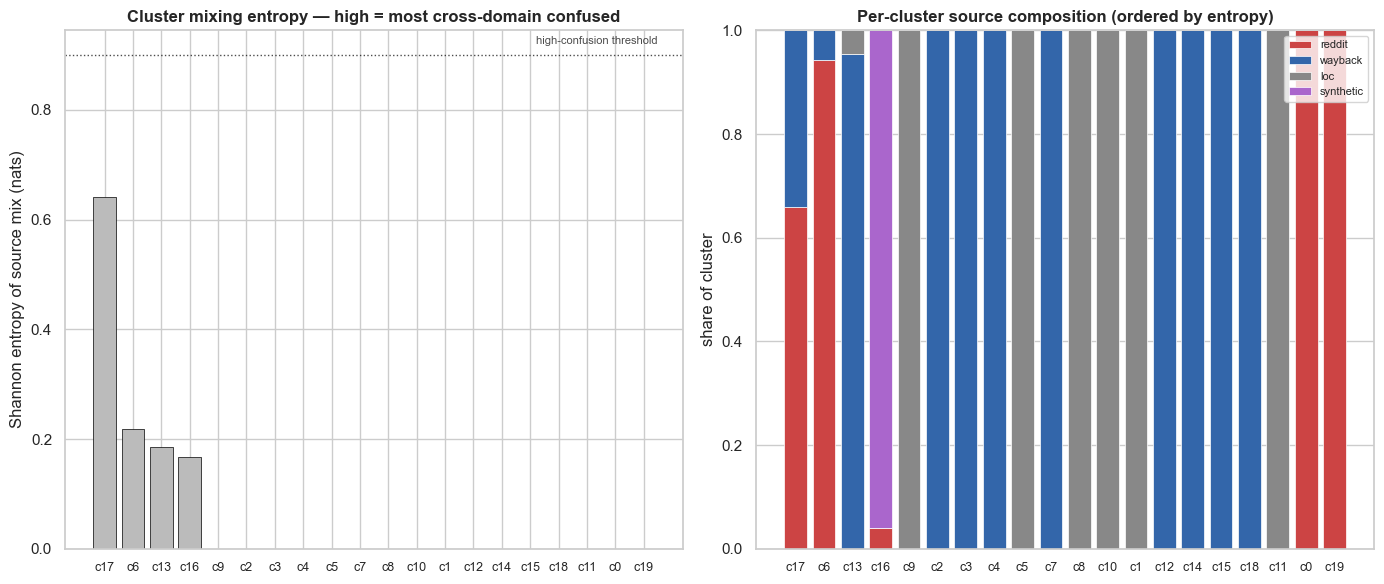

✓ Saved figure: /Users/rao/Library/Application Support/Claude/local-agent-mode-sessions/6b9b214c-10b0-4e49-8804-78fee7ba4cfe/65bc0ee0-83a2-418a-80ae-8b2eb8d6a0cd/local_cc966565-ccf9-44a8-bd4f-b759a867e830/outputs/Chapter_2/Clustering/Outputs/cluster_mixing_overview.png


In [7]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: clusters ranked by mixing entropy, with bar coloured by dominant source
cdf = cluster_df.sort_values("mixing_entropy", ascending=False).reset_index(drop=True)
bars = axes[0].bar(
    range(len(cdf)), cdf["mixing_entropy"],
    color=["#7755aa" if e > 0.9 else "#bbbbbb" for e in cdf["mixing_entropy"]],
    edgecolor="black", linewidth=0.5,
)
axes[0].set_xticks(range(len(cdf)))
axes[0].set_xticklabels([f"c{int(c)}" for c in cdf["cluster"]], rotation=0, fontsize=9)
axes[0].set_ylabel("Shannon entropy of source mix (nats)")
axes[0].set_title("Cluster mixing entropy — high = most cross-domain confused", weight="bold")
axes[0].axhline(0.9, color="black", linestyle=":", linewidth=1, alpha=0.7)
axes[0].text(len(cdf)-0.5, 0.92, "high-confusion threshold", ha="right", fontsize=8, color="black", alpha=0.7)

# Panel B: stacked share of sources per cluster
share_cols = ["share_reddit", "share_wayback", "share_loc", "share_synthetic"]
colors = ["#cc4444", "#3366aa", "#888888", "#aa66cc"]
bottom = np.zeros(len(cdf))
for col, color in zip(share_cols, colors):
    axes[1].bar(range(len(cdf)), cdf[col], bottom=bottom, color=color, edgecolor="white", linewidth=0.5, label=col.replace("share_", ""))
    bottom += cdf[col].values
axes[1].set_xticks(range(len(cdf)))
axes[1].set_xticklabels([f"c{int(c)}" for c in cdf["cluster"]], rotation=0, fontsize=9)
axes[1].set_ylabel("share of cluster")
axes[1].set_title("Per-cluster source composition (ordered by entropy)", weight="bold")
axes[1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
fig_path = OUT_DIR / "cluster_mixing_overview.png"
plt.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"✓ Saved figure: {fig_path}")

## 7. K-means projected onto the SBERT t-SNE map

Overlay the cluster membership on the t-SNE plot from Chapter 2.1. This gives us a single image that shows *both* the source distribution (we can see the four colours from the vectorisation comparison) *and* the K-means partition (drawn as polygon outlines or coloured by cluster). Useful to include in the report as a 'this is the topology the architecture is generated from' figure.

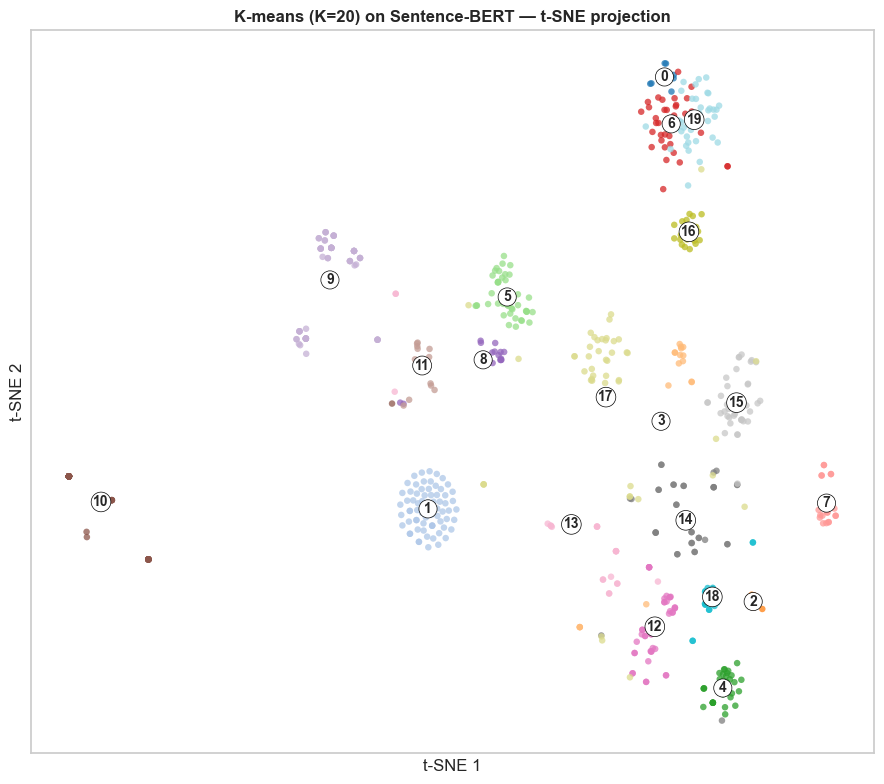

✓ Saved figure: /Users/rao/Library/Application Support/Claude/local-agent-mode-sessions/6b9b214c-10b0-4e49-8804-78fee7ba4cfe/65bc0ee0-83a2-418a-80ae-8b2eb8d6a0cd/local_cc966565-ccf9-44a8-bd4f-b759a867e830/outputs/Chapter_2/Clustering/Outputs/kmeans_on_tsne.png


In [8]:
tsne_sbert = np.load(DATA_PROCESSED / "tsne_sbert.npy")

fig, ax = plt.subplots(figsize=(9, 8))
cluster_colors = plt.cm.tab20(np.linspace(0, 1, K))
for c in range(K):
    m = (df["cluster"] == c).values
    ax.scatter(tsne_sbert[m, 0], tsne_sbert[m, 1],
               s=22, c=[cluster_colors[c]], alpha=0.75, edgecolor="none", label=f"c{c}")
    # cluster label at the centroid
    cx, cy = tsne_sbert[m, 0].mean(), tsne_sbert[m, 1].mean()
    ax.text(cx, cy, str(c), fontsize=10, weight="bold",
            ha="center", va="center",
            bbox=dict(boxstyle="circle,pad=0.15", fc="white", ec="black", linewidth=0.5))
ax.set_title(f"K-means (K={K}) on Sentence-BERT — t-SNE projection", weight="bold")
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
fig_path = OUT_DIR / "kmeans_on_tsne.png"
plt.tight_layout()
plt.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"✓ Saved figure: {fig_path}")

## 8. Build the fragment-driver table

This is the **handover artefact** to Chapter 3. For each cluster (20 in total) we produce a single row with everything Blender will need to construct one architectural fragment: the cluster id (= fragment id), size, mixing entropy, source shares, the 10 soul words, and the cluster centroid in SBERT space (which is used as the *geometric parameter vector* by the Blender geometry-nodes pipeline).

The first 50 dimensions of the centroid are saved alongside — those are what the Blender script reads to drive scale, twist, hollow, subdivision, etc.

The clusters are sorted by `mixing_entropy` descending so that the *most mis-classified* cluster becomes fragment 1 and the *least mis-classified* cluster becomes fragment 20. This rank IS a design parameter.

In [9]:
# centroids in SBERT space
centroids = kmeans.cluster_centers_   # (K, 384)

fragments = []
rank_table = cluster_df.sort_values("mixing_entropy", ascending=False).reset_index(drop=True)
for rank, (_, row) in enumerate(rank_table.iterrows(), 1):
    c        = int(row["cluster"])
    cent     = centroids[c]
    sw       = soul_words[c]
    fragments.append({
        "fragment_id":     f"frag_{rank:02d}",
        "rank":            rank,                # 1 = most mixed (thesis-aligned)
        "cluster":         c,
        "size":            int(row["size"]),
        "mixing_entropy":  float(row["mixing_entropy"]),
        "n_sources":       int(row["n_sources"]),
        "share_reddit":    float(row["share_reddit"]),
        "share_wayback":   float(row["share_wayback"]),
        "share_loc":       float(row["share_loc"]),
        "share_synthetic": float(row["share_synthetic"]),
        "soul_words":      ", ".join(w for w, _ in sw),
        # 10 geometry-driver scalars derived from the centroid (PCA-50 of SBERT space).
        # Saved as a comma-separated list so it survives CSV round-trips.
        "centroid_top10":  ", ".join(f"{v:+.4f}" for v in cent[:10]),
    })
frag_df = pd.DataFrame(fragments)
frag_df.head(20)

,fragment_id,rank,cluster,size,mixing_entropy,n_sources,share_reddit,share_wayback,share_loc,share_synthetic,soul_words,centroid_top10
0,frag_01,1,17,47,0.6413,2,0.660,0.340,0.000,0.00,"https, archive, lost, pilot, org, com, media, ...","-0.0519, -0.0055, -0.0042, -0.0095, +0.0493, +..."
1,frag_02,2,6,35,0.2190,2,0.943,0.057,0.000,0.00,"love, dad, miss, life, years, ago, died, happy...","-0.0099, +0.0156, +0.0574, +0.0263, +0.0441, +..."
2,frag_03,3,13,22,0.1849,2,0.000,0.955,0.045,0.00,"windmill, chitty, windmills, bang, bang bang, ...","-0.0070, +0.0043, +0.0090, +0.0151, +0.0241, -..."
3,frag_04,4,16,25,0.1679,2,0.040,0.000,0.000,0.96,"laughter, room, soft, small, worn, scent, ligh...","+0.0119, -0.0006, +0.0898, +0.0699, +0.0999, +..."
4,frag_05,5,9,60,-0.0000,1,0.000,0.000,1.000,0.00,"glass, negatives portrait, glass glass, man ne...","-0.0226, +0.1268, -0.0126, +0.0165, -0.0188, -..."
5,frag_06,6,2,13,-0.0000,1,0.000,1.000,0.000,0.00,"siliconvalley, geocities siliconvalley, comput...","-0.0073, -0.1027, +0.0126, -0.0026, -0.0522, -..."
6,frag_07,7,3,17,-0.0000,1,0.000,1.000,0.000,0.00,"2003, не, что, на, dmitry, subject, это, die, ...","-0.0176, -0.0194, -0.0017, -0.0113, -0.0318, +..."
7,frag_08,8,4,33,-0.0000,1,0.000,1.000,0.000,0.00,"petsburgh, geocities, geocities petsburgh, com...","+0.0047, -0.0420, +0.0139, +0.0074, -0.0055, -..."
8,frag_09,9,5,44,-0.0000,1,0.000,0.000,1.000,0.00,"theater, united states, united, states, design...","-0.0112, +0.0372, -0.0280, -0.0338, -0.0589, +..."
9,frag_10,10,7,24,-0.0000,1,0.000,1.000,0.000,0.00,"athens, geocities athens, geocities, arts, hom...","-0.0246, +0.0201, +0.0349, -0.0072, -0.0061, -..."


In [10]:
# Save everything Chapter 3 needs.
df.to_csv(DATA_PROCESSED / "cluster_assignments.csv", index=False, encoding="utf-8")
cluster_df.to_csv(OUT_DIR / "cluster_summary.csv", index=False, encoding="utf-8")
frag_df.to_csv(OUT_DIR / "fragment_drivers.csv", index=False, encoding="utf-8")
np.save(DATA_PROCESSED / "kmeans_centroids.npy", centroids)
with open(OUT_DIR / "soul_words.json", "w", encoding="utf-8") as f:
    json.dump({str(c): [(w, s) for w, s in soul_words[c]] for c in soul_words}, f, indent=2)

print("✓ Saved:")
print(f"   {DATA_PROCESSED / 'cluster_assignments.csv'}")
print(f"   {OUT_DIR / 'cluster_summary.csv'}")
print(f"   {OUT_DIR / 'fragment_drivers.csv'}     ← Chapter 3 main handover")
print(f"   {DATA_PROCESSED / 'kmeans_centroids.npy'}")
print(f"   {OUT_DIR / 'soul_words.json'}")

✓ Saved:
   /Users/rao/Library/Application Support/Claude/local-agent-mode-sessions/6b9b214c-10b0-4e49-8804-78fee7ba4cfe/65bc0ee0-83a2-418a-80ae-8b2eb8d6a0cd/local_cc966565-ccf9-44a8-bd4f-b759a867e830/outputs/data/processed/cluster_assignments.csv
   /Users/rao/Library/Application Support/Claude/local-agent-mode-sessions/6b9b214c-10b0-4e49-8804-78fee7ba4cfe/65bc0ee0-83a2-418a-80ae-8b2eb8d6a0cd/local_cc966565-ccf9-44a8-bd4f-b759a867e830/outputs/Chapter_2/Clustering/Outputs/cluster_summary.csv
   /Users/rao/Library/Application Support/Claude/local-agent-mode-sessions/6b9b214c-10b0-4e49-8804-78fee7ba4cfe/65bc0ee0-83a2-418a-80ae-8b2eb8d6a0cd/local_cc966565-ccf9-44a8-bd4f-b759a867e830/outputs/Chapter_2/Clustering/Outputs/fragment_drivers.csv     ← Chapter 3 main handover
   /Users/rao/Library/Application Support/Claude/local-agent-mode-sessions/6b9b214c-10b0-4e49-8804-78fee7ba4cfe/65bc0ee0-83a2-418a-80ae-8b2eb8d6a0cd/local_cc966565-ccf9-44a8-bd4f-b759a867e830/outputs/data/processed/kmeans_c

## Notes for the report

1. **Why K = 20.** The assignment requires *at least 20 rule-generated architectural fragments showing iterative variation*. Choosing K = 20 makes the one-to-one mapping between *cluster* and *fragment* explicit; every fragment is the geometric translation of one cluster's centroid + soul words.
2. **Mixing entropy is the design parameter.** The thesis claims that AI-imposed connections between unrelated digital remains are the project's generative engine. Mixing entropy quantifies that claim: it is the empirical measure of how confused a cluster is, and the Blender pipeline reads it as a *strength* parameter. High-entropy fragments are deliberately more deformed than low-entropy ones — visible confusion becomes visible geometry.
3. **Silhouette is not the criterion.** We print it for transparency, but a high silhouette would only mean the clusters are clean — i.e. unmixed — which is the *opposite* of what this project wants. Low-but-positive silhouette + high entropy at the top of the rank is the project's correct state.
4. **What the 'soul words' do.** They make each cluster verbally legible. Without them, fragment 7 (say) is just a high-dimensional point in SBERT space. With them, fragment 7 is *the cluster of fragments unified by the words 'mother, kitchen, hum, html, brown, light, year, never, somewhere, gone'* — which is the kind of label the report can quote and the Blender scene can subtitle.